In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import re
import os.path as op
from typing import Tuple, Iterator
# EEG utilities
import mne
# BIDS utilities
from util.io.bids import DataSink
from bids import BIDSLayout
# PLV functions
from util.io.ffr import read_epochs
# from util.io.plv import *
from scipy.stats import shapiro, mannwhitneyu
from arch.bootstrap import IIDBootstrap

### Compute PLVs

In [18]:
def read_epochs(BIDS_ROOT, sub, desc):
    '''
    reads and concatenates epochs across runs
    '''
    from bids import BIDSLayout
    layout = BIDSLayout(BIDS_ROOT, derivatives = True)
    run = lambda f: int(re.findall('run-(\w+)_', f)[0])
    fnames = layout.get(
        return_type = 'filename',
        subject = sub, 
        desc = desc
        )
    print(fnames)
    fnames.sort(key = run)
    epochs_all = [mne.read_epochs(f) for f in fnames]
    epochs = mne.concatenate_epochs(epochs_all)
    epochs = epochs.pick('eeg')
    return epochs

condition_mapping = {
    '11': [130, 130], # [target freq, stim freq]
    '12': [130, 200],
    '13': [130, 280],
    '21': [200, 130],
    '22': [200, 200],
    '23': [200, 280],
    '31': [280, 130],
    '32': [280, 200],
    '33': [280, 280],
}

def add_metadata(epochs, condition_mapping):
    mapping = {epochs.event_id[key]: key for key in epochs.event_id}
    tags = np.array([mapping[ev] for ev in epochs.events[:, -1]])
    target = np.array([condition_mapping[tag][0] for tag in tags])
    stim = np.array([condition_mapping[tag][1] for tag in tags])
    df = pd.DataFrame({'target': target, 'stim': stim})
    epochs.metadata = df
    return epochs

In [19]:
# np.random.seed(42)

# BIDS_ROOT = '../data/bids'
# DERIV_ROOT = '../data/bids/derivatives'
# layout = BIDSLayout(BIDS_ROOT, derivatives = True)
# subs = layout.get_subjects(scope = 'preprocess_ffr')
# subs.sort(key = int)

# stim_freqs = [130, 200, 280]

# # Bootstrapping params
# draws = 1000
# n_obs = 400 # determined using find-n-epochs-per-conditions.ipynb

# # Load the data from one subject
# for sub in subs:

#     # read FFR epochs
#     epochs = read_epochs(BIDS_ROOT, sub, 'forFFR')

#     # Crop
#     epochs = epochs.crop(tmin = 0)

#     # Add condition labels
#     epochs = add_metadata(epochs, condition_mapping)
    
#     sub_plvs = pd.DataFrame()
#     for stim_freq in stim_freqs:
#         plvs = np.array([])
#         for i in range(draws):
            
#             # Select data by condition
#             data_array = epochs[f"stim == {stim_freq}"].get_data(copy = True)
#             data_array = np.squeeze(data_array)
            
#             # Draw n random observations
#             draw = data_array[np.random.randint(1, np.shape(data_array)[0], n_obs), :]
        
#             # Constants for computing FFT
#             N = np.shape(draw)[1] # time points
#             fs = 5000 # sampling rate
#             T = 1/fs # msec of each time point
        
#             # Compute FFTs of each signal
#             ffts = np.fft.fft(draw)
                
#             # # Extract the frequency bin of interest (e.g., approximating 10 Hz)
#             freqs = np.fft.fftfreq(N, d = T) 
#             idx = np.abs(freqs - stim_freq).argmin()
        
#             # Extract the phase information
#             phases = np.angle(ffts[:, idx])
            
#             # Compute the PLV as the average value for the draw
#             plv = np.abs(np.mean(np.exp(1j * phases)))
#             plvs = np.append(plvs, plv)
        
#             # Plot
#             # plot_polar_vectors(phases)
#             # break
    
#         # Create dataframe
#         condition_plvs = pd.DataFrame({
#             'sub': sub,
#             'stim_freq': stim_freq,
#             'draw': list(range(1, draws+1)),
#             'plv': plvs
#         })
#         sub_plvs = pd.concat([sub_plvs, condition_plvs], ignore_index = True)

#     sink = DataSink(DERIV_ROOT, 'plv')
#     path = sink.make_dir(sub)
#     fname = op.join(path, 'plv.csv')
#     sub_plvs.to_csv(fname, index = False)
#     # break

### PLVs to each tone

In [20]:
fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')

plvs = pd.DataFrame()
for fpath in fpaths:
    plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

plvs

,sub,stim_freq,draw,plv
0,7,130,1,0.030975
1,7,130,2,0.033188
2,7,130,3,0.013108
3,7,130,4,0.057135
4,7,130,5,0.074935
...,...,...,...,...
125995,35,280,996,0.059334
125996,35,280,997,0.113223
125997,35,280,998,0.013293
125998,35,280,999,0.049950


<Axes: xlabel='plv', ylabel='Count'>

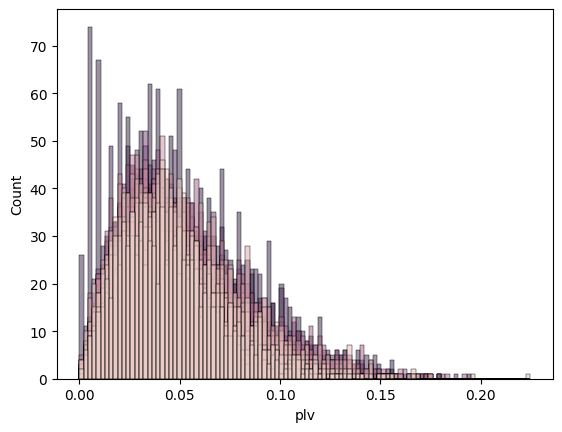

In [21]:
# 130 Hz 
plvs_130 = plvs[plvs.stim_freq == 130]
sns.histplot(plvs_130, x = "plv", hue = "sub", legend = False)

<Axes: xlabel='plv', ylabel='Count'>

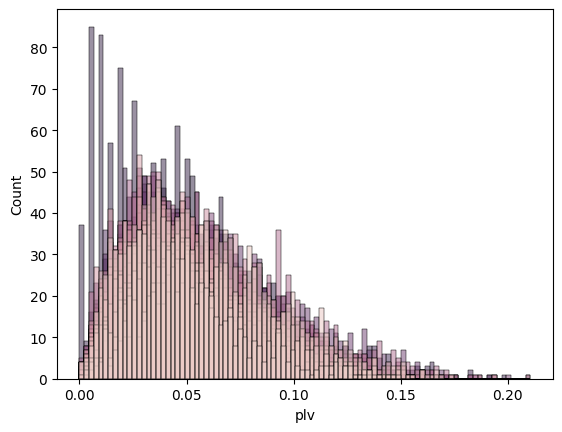

In [22]:
# 200 Hz 
plvs_200 = plvs[plvs.stim_freq == 200]
sns.histplot(plvs_200, x = "plv", hue = "sub", legend = False)

<Axes: xlabel='plv', ylabel='Count'>

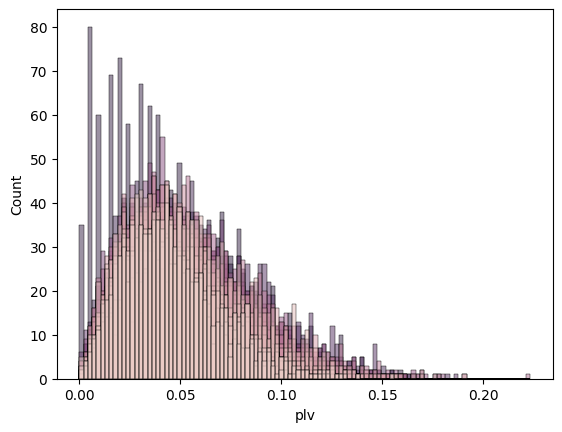

In [23]:
# 280 Hz
plvs_280 = plvs[plvs.stim_freq == 280]
sns.histplot(plvs_280, x = "plv", hue = "sub", legend = False)

# PLVs by accuracy

In [26]:
# Functions for computing effects sizes for mann-whitney U
def Z_from_U(n1, n2, U):
    mean_U = n1 * n2 / 2
    sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    
    z = (U - mean_U) / sd_U
    return z

def cohens_r(n1, n2, z):
    N = n1 + n2
    r = z / np.sqrt(N)
    return r

In [27]:
# Regenerate null, but in a dataframe
np.random.seed(42)
draws = 1000
subs = 1000
null = np.array([])

for i in range(subs):
    plvs = list()
    for j in range(draws):
        # Draw random phases from a uniform distribution
        phases = np.random.uniform(low = 0, high = 2*np.pi, size = 400)
        plv = np.abs(np.mean(np.exp(1j * phases)))
        plvs.append(plv)
    mean_plv = np.mean(plvs)
    null = np.append(null, mean_plv)


# Get 95% CI
CI90 = np.percentile(null, 90)
print(f'90% CI: {CI90}')
CI95 = np.percentile(null, 95)
print(f'95% CI: {CI95}')

# Create null dataframe
null = pd.DataFrame({
    'subj': 'null',
    'accuracy_group': 'null',
    'plv': null,
    'stim_freq': 'null'
})

90% CI: 0.04526546386691893
95% CI: 0.045550714538532794


In [28]:
fpaths = glob.glob('../data/bids/derivatives/plv/sub-*/*.csv')
plvs = pd.DataFrame()
for fpath in fpaths:
    plvs = pd.concat([plvs, pd.read_csv(fpath, index_col = False)], ignore_index = True)

In [29]:
# Add accuracy group to dataframe
accuracy = pd.read_csv('accuracy.csv', index_col = 0)
accuracy = accuracy.rename(columns = {'subject': 'subj'})
accuracy = accuracy.rename(columns = {'score_group': 'accuracy_group'})
plvs = plvs.rename(columns = {'sub': 'subj'})
plvs = plvs.merge(accuracy, left_on = ["subj"], right_on = ["subj"])
plvs

,subj,stim_freq,draw,plv,accuracy,accuracy_group
0,7,130,1,0.030975,0.915718,low
1,7,130,2,0.033188,0.915718,low
2,7,130,3,0.013108,0.915718,low
3,7,130,4,0.057135,0.915718,low
4,7,130,5,0.074935,0.915718,low
...,...,...,...,...,...,...
125995,35,280,996,0.059334,0.980110,high
125996,35,280,997,0.113223,0.980110,high
125997,35,280,998,0.013293,0.980110,high
125998,35,280,999,0.049950,0.980110,high


In [30]:
# # Readjust median split
# med = np.median(plvs.accuracy)
# print(med)
# plvs.loc[plvs['accuracy'] > med, 'accuracy_group'] = 'high'
# plvs.loc[plvs['accuracy'] < med, 'accuracy_group'] = 'low'

### 130 Hz

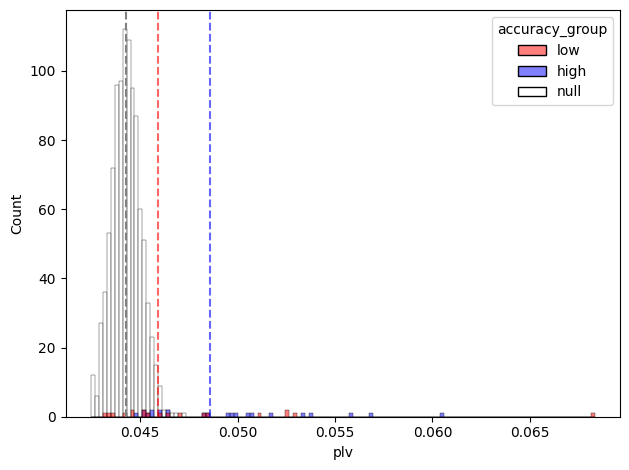

In [31]:
plvs_130 = plvs[plvs.stim_freq == 130]
plvs_130 = plvs_130.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_130 = pd.concat([plvs_130, null])
sns.histplot(plvs_130, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_130[plvs_130.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_130[plvs_130.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_130[plvs_130.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
# plt.savefig("../figs/PLV-130-hz.png", dpi = 300)

In [32]:
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_130[plvs_130.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_130.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
descriptives

low BCa 95% CI: [0.04464784] [0.04823136]
high BCa 95% CI: [0.04602568] [0.05045459]


,accuracy_group,med,Q1,Q3,IQR
0,high,0.048555,0.045816,0.051226,0.005410
1,low,0.045933,0.044663,0.049842,0.005179
2,null,0.044272,0.043786,0.044775,0.000989


**Tests**

In [33]:
high = plvs_130[plvs_130.accuracy_group == 'high']
low = plvs_130[plvs_130.accuracy_group == 'low']
null = plvs_130[plvs_130.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.8883525133132935, pvalue=0.014656975865364075)
ShapiroResult(statistic=0.7237424254417419, pvalue=0.00010814608685905114)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 22300.0, p = 6.355970069162389e-15, r = 0.24102531844408437
low vs null: u = 22300.0, p = 1.223166267838532e-05, r = 0.31552706253508644
high vs low: u = 289.0, p = 0.03845173520934555, r = 0.2749034236223175


### 200 Hz

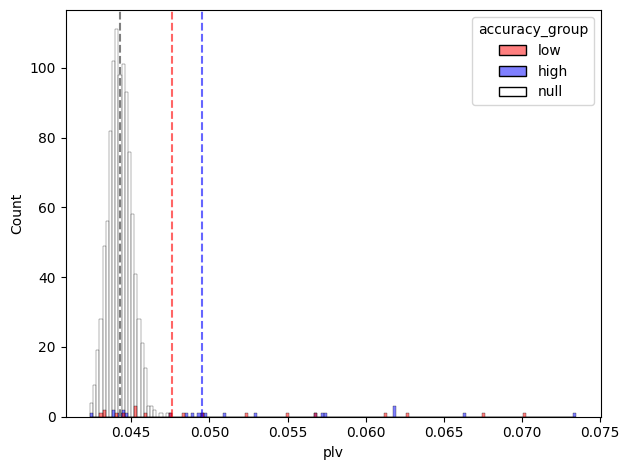

In [34]:
plvs_200 = plvs[plvs.stim_freq == 200]
plvs_200 = plvs_200.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_200 = pd.concat([plvs_200, null])
sns.histplot(plvs_200, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_200[plvs_200.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
# plt.savefig("../figs/PLV-200-hz.png", dpi = 300)

**Stats**

In [35]:
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_200[plvs_200.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_200.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
descriptives

low BCa 95% CI: [0.0444599] [0.0524093]
high BCa 95% CI: [0.04476984] [0.05671206]


,accuracy_group,med,Q1,Q3,IQR
0,high,0.049542,0.044664,0.057260,0.012597
1,low,0.047590,0.044870,0.055964,0.011094
2,null,0.044272,0.043786,0.044775,0.000989


**Tests**

In [36]:
high = plvs_200[plvs_200.accuracy_group == 'high']
low = plvs_200[plvs_200.accuracy_group == 'low']
null = plvs_200[plvs_200.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.9000139832496643, pvalue=0.025296542793512344)
ShapiroResult(statistic=0.8375034332275391, pvalue=0.004228716250509024)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 19060.0, p = 3.407652669038444e-08, r = 0.16871772291085907
low vs null: u = 19060.0, p = 9.26691730660956e-06, r = 0.2356592748308927
high vs low: u = 243.0, p = 0.2720931928031376, r = 0.09553381388293304


### 280 Hz

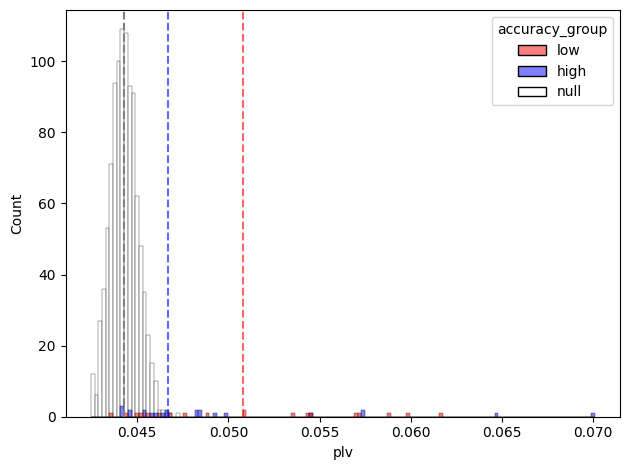

In [39]:
plvs_280 = plvs[plvs.stim_freq == 280]
plvs_280 = plvs_280.groupby(['subj', 'accuracy_group'], as_index=False)['plv'].mean()
plvs_280 = pd.concat([plvs_280, null])
sns.histplot(plvs_280, x = "plv", hue = "accuracy_group", palette={"high": "blue", "low": "red", "null": "white"})
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'high'].plv), color='blue', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'low'].plv), color='red', linestyle='--', alpha = 0.6)
plt.axvline(np.median(plvs_280[plvs_280.accuracy_group == 'null'].plv), color='grey', linestyle='--')
plt.tight_layout()
# plt.savefig("../figs/PLV-280-hz.png", dpi = 300)

**Stats**

In [40]:
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'low'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("low BCa 95% CI:", ci[0], ci[1])
bs = IIDBootstrap(plvs_280[plvs_280.accuracy_group == 'high'].plv)
ci = bs.conf_int(np.median, reps=10000, method='bca')
print("high BCa 95% CI:", ci[0], ci[1])

descriptives = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].median()
descriptives = descriptives.rename(columns = {'plv': 'med'})
descriptives['Q1'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.25).plv
descriptives['Q3'] = plvs_280.groupby(['accuracy_group'], as_index=False)['plv'].quantile(0.75).plv
descriptives['IQR'] = descriptives.Q3 - descriptives.Q1
descriptives

low BCa 95% CI: [0.04559498] [0.05430516]
high BCa 95% CI: [0.04541733] [0.04851041]


,accuracy_group,med,Q1,Q3,IQR
0,high,0.046706,0.045386,0.049600,0.004213
1,low,0.050819,0.045939,0.055743,0.009804
2,null,0.044272,0.043786,0.044775,0.000989


**Tests**

In [41]:
high = plvs_280[plvs_280.accuracy_group == 'high']
low = plvs_280[plvs_280.accuracy_group == 'low']
null = plvs_280[plvs_280.accuracy_group == 'null']

print('test for normality')
print(shapiro(high.plv))
print(shapiro(low.plv))
print(shapiro(null.plv))

print('compare groups')
u, p = mannwhitneyu(high.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(null.plv), u)
r = cohens_r(len(high.plv), len(null.plv), z)
print(f'high vs null: u = {u}, p = {p}, r = {r}')
pu, p = mannwhitneyu(low.plv, null.plv, alternative = 'greater')
z = Z_from_U(len(low.plv), len(null.plv), u)
r = cohens_r(len(low.plv), len(null.plv), z)
print(f'low vs null: u = {u}, p = {p}, r = {r}')
u, p = mannwhitneyu(high.plv, low.plv, alternative = 'greater')
z = Z_from_U(len(high.plv), len(low.plv), u)
r = cohens_r(len(high.plv), len(low.plv), z)
print(f'high vs low: u = {u}, p = {p}, r = {r}')

test for normality
ShapiroResult(statistic=0.7507975697517395, pvalue=6.893932004459202e-05)
ShapiroResult(statistic=0.9240527153015137, pvalue=0.13448750972747803)
ShapiroResult(statistic=0.9964521527290344, pvalue=0.023049497976899147)
compare groups
high vs null: u = 20529.0, p = 5.797347614210471e-11, r = 0.2015016296510776
low vs null: u = 20529.0, p = 2.511344104607818e-10, r = 0.27187093536714596
high vs low: u = 177.0, p = 0.8557380856128591, r = -0.16182258269966207
